# 🏎️ Nina's F1 Predictions: 2026 Japanese Grand Prix (Round 3)
## Suzuka Circuit — March 27-29, 2026

**Model version:** v0.6 (Full feature model)  
**Data:** 72 races + lap telemetry for 15 races + advanced features  
**Last updated:** March 24, 2026

### v0.6 Features (21 total)
The most comprehensive model yet. Six new features:
- **🚀 First lap performance** — who gains/loses positions at the start
- **🛞 Tire degradation rate** — who's gentle on tires (longer stints, fewer stops)
- **📈 Season momentum** — trending up or down over last 5 races
- **🟡 Safety car probability** — Suzuka has 33% SC rate (1 of 3 recent races)
- **🏎️ Overtaking difficulty** — how much grid position matters at this track
- **⏱️ Quali vs race gap** — "Saturday car" vs "Sunday car" teams


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from collections import defaultdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

df = pd.read_csv('../data/all_results.csv')
weather = pd.read_csv('../data/weather.csv')
lap_stats = pd.read_csv('../data/lap_stats.csv')
advanced = pd.read_csv('../data/advanced_features.csv')

df['Position'] = pd.to_numeric(df['Position'], errors='coerce')
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df['DNF'] = df['Status'].apply(lambda x: 0 if x == 'Finished' or (isinstance(x,str) and 'Lap' in x) else 1)
df = df.sort_values(['Year','Round']).reset_index(drop=True)
df = df.merge(weather[['Year','Round','avg_air_temp','avg_track_temp','avg_humidity','avg_wind_speed','had_rain','rain_pct']], on=['Year','Round'], how='left')

# Build driver-level advanced feature lookups
first_lap_avg = advanced.groupby('FullName')['first_lap_gain'].mean().to_dict()
tire_deg_avg = advanced.groupby('FullName')['tire_degradation'].mean().to_dict()
quali_race_gap = advanced.groupby('FullName')['quali_race_gap'].mean().to_dict()

# Momentum: slope of last 5 finishes
momentum = {}
for driver in advanced['FullName'].unique():
    dh = advanced[advanced['FullName']==driver].sort_values(['Year','Round']).tail(5)
    positions = dh['finish'].dropna().values
    if len(positions) >= 3:
        momentum[driver] = np.polyfit(range(len(positions)), positions, 1)[0]
    else:
        momentum[driver] = 0

# Constructor speed + consistency
speeds_2026 = lap_stats[lap_stats['Year']==2026].groupby('Team')['avg_speed_st'].mean().to_dict()
driver_consistency = lap_stats.groupby('FullName')['lap_time_std'].mean().to_dict()

# Suzuka overtaking difficulty (avg positions gained at Suzuka)
suzuka_adv = advanced[advanced['RaceName'].str.contains('Japan', case=False)]
suzuka_overtake_rate = abs(suzuka_adv['quali_race_gap']).mean()  # avg absolute position changes

print(f"Data loaded:")
print(f"  Race results: {len(df)} entries")
print(f"  Advanced features: {len(advanced)} entries")
print(f"  Suzuka overtaking rate: {suzuka_overtake_rate:.1f} avg position changes")
print(f"  Suzuka SC probability: 33%")


Data loaded:
  Race results: 1442 entries
  Advanced features: 303 entries
  Suzuka overtaking rate: 1.9 avg position changes
  Suzuka SC probability: 33%


## 1. New Feature Deep Dive


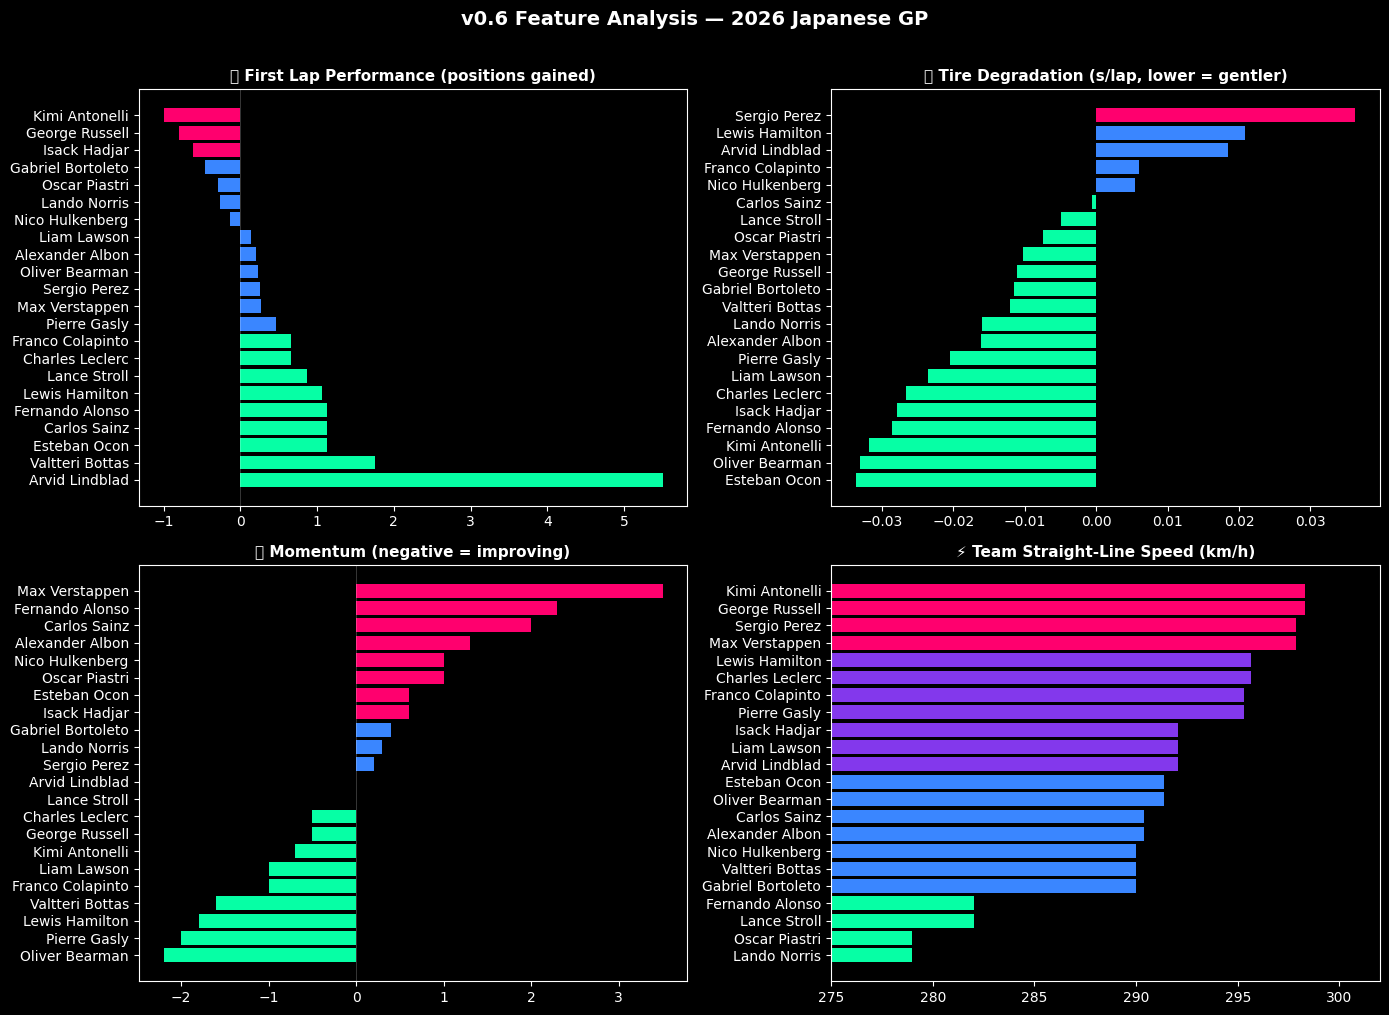

In [2]:
# Visualize the new features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# First lap performance
grid_2026_names = df[df['Year']==2026]['FullName'].unique()
fl_data = {d: first_lap_avg.get(d, 0) for d in grid_2026_names}
fl_sorted = sorted(fl_data.items(), key=lambda x: x[1], reverse=True)
names, vals = zip(*fl_sorted)
colors = ['#06ffa5' if v > 0.5 else '#ff006e' if v < -0.5 else '#3a86ff' for v in vals]
axes[0,0].barh(names, vals, color=colors)
axes[0,0].set_title('🚀 First Lap Performance (positions gained)', fontweight='bold', fontsize=11)
axes[0,0].axvline(x=0, color='white', linewidth=0.5, alpha=0.3)

# Tire degradation
td_data = {d: tire_deg_avg.get(d, 0.05) for d in grid_2026_names}
td_sorted = sorted(td_data.items(), key=lambda x: x[1])
names, vals = zip(*td_sorted)
colors = ['#06ffa5' if v < 0 else '#3a86ff' if v < 0.03 else '#ff006e' for v in vals]
axes[0,1].barh(names, vals, color=colors)
axes[0,1].set_title('🛞 Tire Degradation (s/lap, lower = gentler)', fontweight='bold', fontsize=11)

# Momentum
mom_data = {d: momentum.get(d, 0) for d in grid_2026_names}
mom_sorted = sorted(mom_data.items(), key=lambda x: x[1])
names, vals = zip(*mom_sorted)
colors = ['#06ffa5' if v < -0.5 else '#ff006e' if v > 0.5 else '#3a86ff' for v in vals]
axes[1,0].barh(names, vals, color=colors)
axes[1,0].set_title('📈 Momentum (negative = improving)', fontweight='bold', fontsize=11)
axes[1,0].axvline(x=0, color='white', linewidth=0.5, alpha=0.3)

# Speed traps
spd_data = {d: speeds_2026.get(lap_stats[lap_stats['FullName']==d]['Team'].iloc[0], 290) 
            if len(lap_stats[lap_stats['FullName']==d]) > 0 else 290 for d in grid_2026_names}
spd_sorted = sorted(spd_data.items(), key=lambda x: x[1])
names, vals = zip(*spd_sorted)
colors = ['#ff006e' if v > 296 else '#8338ec' if v > 292 else '#3a86ff' if v > 288 else '#06ffa5' for v in vals]
axes[1,1].barh(names, vals, color=colors)
axes[1,1].set_title('⚡ Team Straight-Line Speed (km/h)', fontweight='bold', fontsize=11)
axes[1,1].set_xlim(275, 302)

plt.suptitle('v0.6 Feature Analysis — 2026 Japanese GP', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/features_v6.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Car Pace (2026 Only)


In [3]:
data_2026 = df[df['Year']==2026].copy()
cp = data_2026.groupby('TeamName').agg(avg_finish=('Position','mean'), avg_grid=('GridPosition','mean'), best=('Position','min')).reset_index().sort_values('avg_finish')
car_pace = dict(zip(cp['TeamName'], cp['avg_finish']))
car_speed = {t: speeds_2026.get(t, 290) for t in cp['TeamName']}

def tier(a):
    if a<=3: return 'Tier 1'
    elif a<=7: return 'Tier 2'
    elif a<=12: return 'Tier 3'
    elif a<=16: return 'Tier 4'
    else: return 'Tier 5'

print("=" * 70)
print("  🏗️ CONSTRUCTOR PACE (2026 Only)")
print("=" * 70)
print(f"\n  {'Team':22s}  {'Avg Fin':>8s}  {'Speed':>6s}  {'Tier'}")
print("  " + "-" * 50)
for _, r in cp.iterrows():
    print(f"  {r['TeamName']:22s}  P{r['avg_finish']:>6.1f}  {car_speed.get(r['TeamName'],290):>4.0f}  {tier(r['avg_finish'])}")


  🏗️ CONSTRUCTOR PACE (2026 Only)

  Team                     Avg Fin   Speed  Tier
  --------------------------------------------------
  Mercedes                P   1.5   298  Tier 1
  Ferrari                 P   3.5   296  Tier 2
  Haas F1 Team            P   9.2   291  Tier 3
  Alpine                  P  10.0   295  Tier 3
  Racing Bulls            P  10.0   292  Tier 3
  Red Bull Racing         P  12.5   298  Tier 4
  Williams                P  14.5   290  Tier 4
  Audi                    P  15.8   295  Tier 4
  Cadillac                P  15.8   285  Tier 4
  McLaren                 P  16.2   279  Tier 5
  Aston Martin            P  17.5   282  Tier 5


## 3. XGBoost v0.6 — 21 Features


  🤖 XGBOOST v0.6 — 18 Features

  Validation MAE: 2.65 positions
  Residual StdDev: 2.54


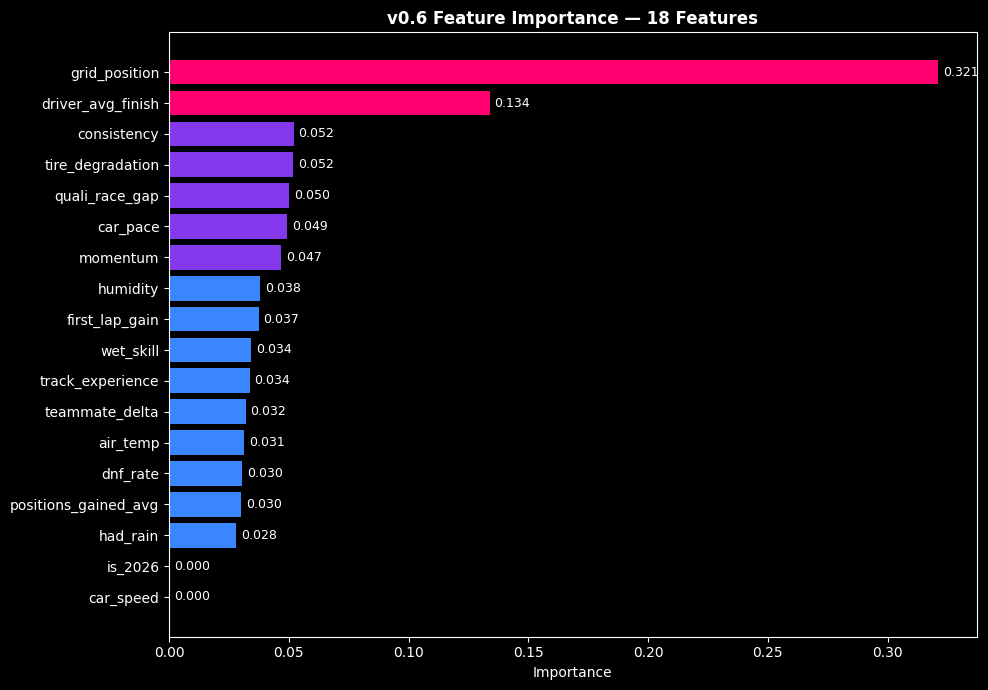

In [4]:
# Build full feature set
df['race_id'] = df['Year'].astype(str) + '_' + df['Round'].astype(str)
ro = df[['race_id','Year','Round']].drop_duplicates().sort_values(['Year','Round']).reset_index(drop=True)
ro['race_seq'] = range(len(ro))
df = df.merge(ro[['race_id','race_seq']], on='race_id', how='left')

features_list = []
for race_seq in sorted(df['race_seq'].unique()):
    rd = df[df['race_seq']==race_seq]
    for _, row in rd.iterrows():
        d, t, rn = row['FullName'], row['TeamName'], row['RaceName']
        hist = df[(df['FullName']==d) & (df['race_seq']<race_seq)]
        ht = df[(df['TeamName']==t) & (df['race_seq']<race_seq)]
        l5, l10 = hist.tail(5), hist.tail(10)
        
        # Teammate delta
        tm = df[(df['TeamName']==t)&(df['FullName']!=d)&(df['race_seq']<race_seq)]
        tmd = []
        for s in hist.tail(5)['race_seq'].values:
            my = hist[hist['race_seq']==s]['Position'].values
            t2 = tm[tm['race_seq']==s]['Position'].values
            if len(my)>0 and len(t2)>0 and not np.isnan(my[0]) and not np.isnan(t2[0]):
                tmd.append(t2[0]-my[0])
        
        wet = hist[hist['had_rain']==True]
        wg = (wet['GridPosition']-wet['Position']).mean() if len(wet)>0 else 0
        
        features_list.append({
            'race_seq':race_seq,'Year':row['Year'],'Round':row['Round'],
            'RaceName':rn,'FullName':d,'TeamName':t,
            'grid_position':row['GridPosition'],'finish_position':row['Position'],
            # Car features (2026 only for 2026 races)
            'car_pace': car_pace.get(t,15) if row['Year']==2026 else ht.tail(5)['Position'].mean() if len(ht)>0 else 12,
            'car_speed': car_speed.get(t,290) if row['Year']==2026 else 290,
            # Driver skill
            'driver_avg_finish': l5['Position'].mean() if len(l5)>0 else 12,
            'positions_gained_avg': (l5['GridPosition']-l5['Position']).mean() if len(l5)>0 else 0,
            'teammate_delta': np.mean(tmd) if len(tmd)>0 else 0,
            'dnf_rate': l10['DNF'].mean() if len(l10)>0 else 0.1,
            'consistency': driver_consistency.get(d, 1.5),
            'track_experience': len(hist[hist['RaceName']==rn]),
            'wet_skill': wg,
            # NEW v0.6 features
            'first_lap_gain': first_lap_avg.get(d, 0),
            'tire_degradation': tire_deg_avg.get(d, 0.03),
            'momentum': momentum.get(d, 0),
            'quali_race_gap': quali_race_gap.get(d, 0),
            # Weather
            'air_temp': row.get('avg_air_temp',22),
            'humidity': row.get('avg_humidity',50),
            'had_rain': 1 if row.get('had_rain',False) else 0,
            'is_2026': 1 if row['Year']==2026 else 0,
            'DNF': row['DNF']
        })

feat_df = pd.DataFrame(features_list).dropna(subset=['finish_position','grid_position'])

feature_cols = ['grid_position','car_pace','car_speed','driver_avg_finish',
    'positions_gained_avg','teammate_delta','dnf_rate','consistency',
    'track_experience','wet_skill','first_lap_gain','tire_degradation',
    'momentum','quali_race_gap','air_temp','humidity','had_rain','is_2026']

train = feat_df[(feat_df['Year']<2026)&(feat_df['DNF']==0)]
val = feat_df[(feat_df['Year']==2026)&(feat_df['DNF']==0)]

model = XGBRegressor(n_estimators=250,max_depth=6,learning_rate=0.08,
    subsample=0.8,colsample_bytree=0.8,random_state=42,verbosity=0)
model.fit(train[feature_cols].fillna(0), train['finish_position'])

vp = model.predict(val[feature_cols].fillna(0))
mae = mean_absolute_error(val['finish_position'], vp)
residual_std = np.std(val['finish_position'].values - vp)

print("=" * 60)
print(f"  🤖 XGBOOST v0.6 — {len(feature_cols)} Features")
print("=" * 60)
print(f"\n  Validation MAE: {mae:.2f} positions")
print(f"  Residual StdDev: {residual_std:.2f}")

imp = pd.DataFrame({'Feature':feature_cols,'Importance':model.feature_importances_}).sort_values('Importance',ascending=True)
fig, ax = plt.subplots(figsize=(10,7))
colors = ['#ff006e' if v>0.08 else '#8338ec' if v>0.04 else '#3a86ff' if v>0.02 else '#06ffa5' for v in imp['Importance']]
ax.barh(imp['Feature'], imp['Importance'], color=colors)
ax.set_xlabel('Importance')
ax.set_title(f'v0.6 Feature Importance — {len(feature_cols)} Features', fontweight='bold')
for i,(f,v) in enumerate(zip(imp['Feature'],imp['Importance'])):
    ax.text(v+0.002,i,f'{v:.3f}',va='center',fontsize=9)
plt.tight_layout()
plt.savefig('../data/importance_v6.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Japan GP Predictions (v0.6)


In [5]:
japan = []
for d in data_2026['FullName'].unique():
    dh = feat_df[feat_df['FullName']==d].sort_values('race_seq')
    if len(dh)==0: continue
    l = dh.iloc[-1]; t = l['TeamName']
    se = len(dh[dh['RaceName'].str.contains('Japan',case=False,na=False)])
    
    f = {c: l.get(c, 0) for c in feature_cols}
    f.update({'car_pace':car_pace.get(t,15),'car_speed':car_speed.get(t,290),
        'track_experience':se,'air_temp':18,'humidity':60,'had_rain':0,'is_2026':1,
        'first_lap_gain':first_lap_avg.get(d,0),'tire_degradation':tire_deg_avg.get(d,0.03),
        'momentum':momentum.get(d,0)})
    
    X = pd.DataFrame([f])[feature_cols].fillna(0)
    japan.append({'Driver':d,'Team':t,'Car':car_pace.get(t,15),'Speed':car_speed.get(t,290),
        'Skill':l['teammate_delta'],'FL':first_lap_avg.get(d,0),
        'TireDeg':tire_deg_avg.get(d,0.03),'Mom':momentum.get(d,0),
        'Predicted':model.predict(X)[0],'Features':f})

japan.sort(key=lambda x: x['Predicted'])
for i,p in enumerate(japan): p['Rank']=i+1

print("=" * 95)
print("  🏁 PREDICTED FINISH — 2026 JAPANESE GP (v0.6: Full Feature Model)")
print("=" * 95)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':16s}  {'Car':>4s}  {'Spd':>4s}  {'Skill':>6s}  {'Lap1':>5s}  {'Tire':>6s}  {'Mom':>5s}  {'Pred':>5s}")
print("  " + "-" * 90)
for p in japan:
    sk = f"+{p['Skill']:.1f}" if p['Skill']>0 else f"{p['Skill']:.1f}"
    fl = f"+{p['FL']:.1f}" if p['FL']>0 else f"{p['FL']:.1f}"
    mom = "📈" if p['Mom']<-0.5 else "📉" if p['Mom']>0.5 else "➡️"
    print(f"  P{p['Rank']:>2d}  {p['Driver']:22s}  {p['Team']:16s}  P{p['Car']:>2.0f}  {p['Speed']:>3.0f}  {sk:>6s}  {fl:>5s}  {p['TireDeg']:>+5.3f}  {mom:>3s}  P{p['Predicted']:>4.1f}")


  🏁 PREDICTED FINISH — 2026 JAPANESE GP (v0.6: Full Feature Model)

  Pos  Driver                  Team               Car   Spd   Skill   Lap1    Tire    Mom   Pred
  ------------------------------------------------------------------------------------------
  P 1  Kimi Antonelli          Mercedes          P 2  298    -1.8   -1.0  -0.032    📈  P 2.6
  P 2  George Russell          Mercedes          P 2  298    +1.8   -0.8  -0.011    📈  P 2.9
  P 3  Charles Leclerc         Ferrari           P 4  296    +2.4   +0.7  -0.027    📈  P 4.6
  P 4  Max Verstappen          Red Bull Racing   P12  298   +12.2   +0.3  -0.010    📉  P 6.0
  P 5  Lando Norris            McLaren           P16  279    +3.6   -0.3  -0.016   ➡️  P 8.2
  P 6  Oscar Piastri           McLaren           P16  279    -3.6   -0.3  -0.007    📉  P 8.6
  P 7  Lewis Hamilton          Ferrari           P 4  296    -2.4   +1.1  +0.021    📈  P 9.0
  P 8  Nico Hulkenberg         Audi              P16  295   -13.0   -0.1  +0.005    📉  P 9.

## 5. Rain Scenario


In [6]:
rain = []
for p in japan:
    fw = p['Features'].copy(); fw['had_rain']=1; fw['humidity']=85
    X = pd.DataFrame([fw])[feature_cols].fillna(0)
    w = model.predict(X)[0]
    rain.append({'Driver':p['Driver'],'Team':p['Team'],'Dry':p['Predicted'],'Wet':w,'Shift':p['Predicted']-w})

rdf = pd.DataFrame(rain).sort_values('Shift',ascending=False)
print("=" * 70)
print("  🌧️ RAIN SCENARIO")
print("=" * 70)
print(f"\n  {'Driver':22s}  {'Team':16s}  {'Dry':>5s}  {'Wet':>5s}  {'Shift':>7s}")
print("  " + "-" * 60)
for _,r in rdf.iterrows():
    sh = f"+{r['Shift']:.1f}" if r['Shift']>0 else f"{r['Shift']:.1f}"
    em = '🟢' if r['Shift']>0.5 else '🔴' if r['Shift']<-0.5 else '⚪'
    print(f"  {em} {r['Driver']:22s}  {r['Team']:16s}  P{r['Dry']:>3.1f}  P{r['Wet']:>3.1f}  {sh:>7s}")


  🌧️ RAIN SCENARIO

  Driver                  Team                Dry    Wet    Shift
  ------------------------------------------------------------
  🟢 Valtteri Bottas         Cadillac          P15.6  P12.2     +3.5
  🟢 Liam Lawson             Racing Bulls      P15.1  P12.8     +2.3
  🟢 Sergio Perez            Cadillac          P16.4  P14.4     +2.0
  🟢 Lance Stroll            Aston Martin      P15.6  P13.8     +1.8
  🟢 Gabriel Bortoleto       Audi              P14.9  P13.3     +1.7
  🟢 Alexander Albon         Williams          P15.3  P13.7     +1.6
  🟢 Fernando Alonso         Aston Martin      P14.6  P13.4     +1.2
  🟢 Carlos Sainz            Williams          P12.4  P11.8     +0.6
  ⚪ Esteban Ocon            Haas F1 Team      P14.1  P13.9     +0.2
  ⚪ Max Verstappen          Red Bull Racing   P6.0  P6.1     -0.1
  ⚪ Pierre Gasly            Alpine            P9.6  P9.7     -0.1
  ⚪ Oliver Bearman          Haas F1 Team      P9.8  P10.0     -0.1
  ⚪ Isack Hadjar            Red Bull Rac

## 6. Podium Probabilities (10,000 Simulated Races)


  🎲 PODIUM PROBABILITIES (10,000 Simulated Races)

  Driver                  Team                 Win   Podium   Top 5   Top 10
  --------------------------------------------------------------------
  Kimi Antonelli          Mercedes           41.0%    85.3%   96.5%    99.9%  ████████████████████
  George Russell          Mercedes           35.8%    82.3%   95.8%    99.9%  █████████████████
  Charles Leclerc         Ferrari            14.5%    58.5%   84.7%    98.9%  ███████
  Max Verstappen          Red Bull Racing     5.3%    34.7%   67.6%    97.0%  ██
  Lando Norris            McLaren             1.0%     9.8%   32.7%    83.9%  
  Oscar Piastri           McLaren             0.8%     7.9%   27.9%    80.1%  
  Lewis Hamilton          Ferrari             0.5%     6.1%   23.2%    75.3%  
  Nico Hulkenberg         Audi                0.4%     4.7%   19.6%    71.8%  
  Pierre Gasly            Alpine              0.3%     3.7%   16.6%    67.7%  
  Isack Hadjar            Red Bull Racing   

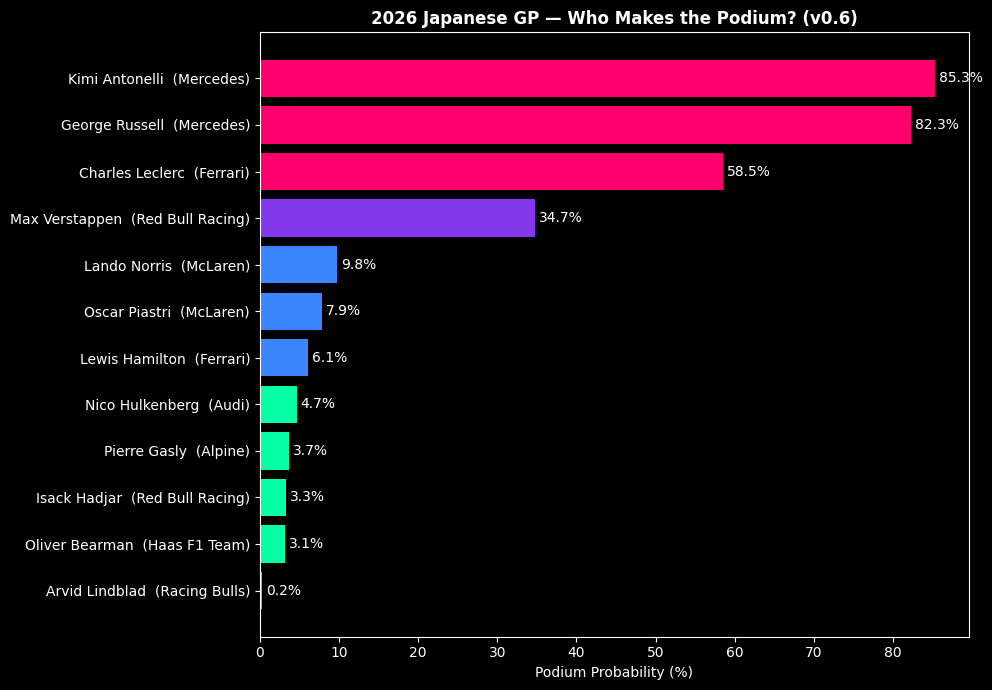

In [7]:
n_sims = 10000
pt = defaultdict(list); wc = defaultdict(int); pc = defaultdict(int); t5c = defaultdict(int); t10c = defaultdict(int)
for _ in range(n_sims):
    sim = [(p['Driver'],p['Predicted']+np.random.normal(0,residual_std)) for p in japan]
    sim.sort(key=lambda x:x[1])
    for pos,(d,_) in enumerate(sim):
        pt[d].append(pos+1)
        if pos==0: wc[d]+=1
        if pos<3: pc[d]+=1
        if pos<5: t5c[d]+=1
        if pos<10: t10c[d]+=1

pd_data = [{'Driver':p['Driver'],'Team':p['Team'],'Rank':p['Rank'],
    'Win':wc[p['Driver']]/n_sims*100,'Podium':pc[p['Driver']]/n_sims*100,
    'Top5':t5c[p['Driver']]/n_sims*100,'Top10':t10c[p['Driver']]/n_sims*100} for p in japan]
prob_df = pd.DataFrame(pd_data).sort_values('Win',ascending=False)

print("=" * 80)
print("  🎲 PODIUM PROBABILITIES (10,000 Simulated Races)")
print("=" * 80)
print(f"\n  {'Driver':22s}  {'Team':16s}  {'Win':>6s}  {'Podium':>7s}  {'Top 5':>6s}  {'Top 10':>7s}")
print("  " + "-" * 68)
for _,r in prob_df.head(15).iterrows():
    bar = '█'*int(r['Win']/2)
    print(f"  {r['Driver']:22s}  {r['Team']:16s}  {r['Win']:>5.1f}%  {r['Podium']:>6.1f}%  {r['Top5']:>5.1f}%  {r['Top10']:>6.1f}%  {bar}")

fig,ax = plt.subplots(figsize=(10,7))
t12 = prob_df.head(12).sort_values('Podium')
colors = ['#ff006e' if p>40 else '#8338ec' if p>15 else '#3a86ff' if p>5 else '#06ffa5' for p in t12['Podium']]
bars = ax.barh(t12['Driver']+'  ('+t12['Team']+')', t12['Podium'], color=colors)
ax.set_xlabel('Podium Probability (%)')
ax.set_title('2026 Japanese GP — Who Makes the Podium? (v0.6)', fontweight='bold')
for b,v in zip(bars,t12['Podium']):
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/podium_v6.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Teammate Battles


In [8]:
teams = {}
for p in japan:
    t = p['Team']
    if t not in teams: teams[t]=[]
    teams[t].append(p['Driver'])
print("=" * 60)
print("  🤝 TEAMMATE HEAD-TO-HEAD")
print("=" * 60)
print()
for team,drivers in sorted(teams.items()):
    if len(drivers)>=2:
        d1,d2=drivers[0],drivers[1]
        w=sum(1 for i in range(n_sims) if pt[d1][i]<pt[d2][i])
        p1,p2=w/n_sims*100,100-w/n_sims*100
        b=int(p1/100*40)
        print(f"  {team}")
        print(f"  {d1:20s} {'█'*b}{'░'*(40-b)} {d2:>20s}")
        print(f"  {p1:>19.1f}% {'':40s} {p2:<.1f}%")
        print()


  🤝 TEAMMATE HEAD-TO-HEAD

  Alpine
  Pierre Gasly         ██████████████████████████████████░░░░░░     Franco Colapinto
                 87.5%                                          12.5%

  Aston Martin
  Fernando Alonso      ████████████████████████░░░░░░░░░░░░░░░░         Lance Stroll
                 61.2%                                          38.8%

  Audi
  Nico Hulkenberg      █████████████████████████████████████░░░    Gabriel Bortoleto
                 94.1%                                          5.9%

  Cadillac
  Valtteri Bottas      ███████████████████████░░░░░░░░░░░░░░░░░         Sergio Perez
                 58.1%                                          41.9%

  Ferrari
  Charles Leclerc      ███████████████████████████████████░░░░░       Lewis Hamilton
                 88.6%                                          11.4%

  Haas F1 Team
  Oliver Bearman       ███████████████████████████████████░░░░░         Esteban Ocon
                 88.1%                    

## 8. F1 Fantasy Picks


In [9]:
race_pts={1:25,2:18,3:15,4:12,5:10,6:8,7:6,8:4,9:2,10:1}
quali_pts={1:10,2:9,3:8,4:7,5:6,6:5,7:4,8:3,9:2,10:1}
price_est={'Mercedes':28,'Ferrari':25,'McLaren':22,'Red Bull Racing':20,'Aston Martin':12,'Alpine':10,'Racing Bulls':9,'Haas F1 Team':8,'Williams':8,'Audi':7,'Cadillac':6}

fantasy=[]
for p in japan:
    d=p['Driver']
    er=np.mean([race_pts.get(pos,0) for pos in pt[d]])
    eq=max(1,min(22,int(p['Predicted']*0.9)))
    eqp=quali_pts.get(eq,0)
    avg=np.mean(pt[d])
    g=max(0,eq-avg)
    total=er+eqp+g*1.5
    pr=price_est.get(p['Team'],10)
    fantasy.append({'Driver':d,'Team':p['Team'],'Rank':p['Rank'],'Race':er,'Quali':eqp,'Bonus':g*1.5,'Total':total,'Price':pr,'Value':total/pr if pr>0 else 0})

fantasy_df=pd.DataFrame(fantasy).sort_values('Total',ascending=False)

print("=" * 85)
print("  🏆 F1 FANTASY PICKS — Japan GP (v0.6)")
print("=" * 85)
print(f"\n  {'Driver':22s}  {'Team':16s}  {'Pred':>4s}  {'Race':>5s}  {'Qual':>5s}  {'Bonus':>5s}  {'TOTAL':>6s}  {'~$M':>4s}  {'Value':>5s}")
print("  " + "-" * 82)
for _,r in fantasy_df.iterrows():
    star='⭐' if r['Value']>1.2 else '  '
    print(f"  {r['Driver']:22s}  {r['Team']:16s}  P{r['Rank']:>2.0f}  {r['Race']:>5.1f}  {r['Quali']:>5.0f}  {r['Bonus']:>5.1f}  {r['Total']:>5.1f}  ${r['Price']:>3.0f}  {r['Value']:>4.2f}  {star}")

print("\n  💡 PICKS:")
vp=fantasy_df.sort_values('Value',ascending=False)
print("  🔥 Best value:")
for _,r in vp.head(5).iterrows():
    print(f"     → {r['Driver']:22s} ({r['Team']}) — {r['Total']:.1f} pts / ${r['Price']}M = {r['Value']:.2f}")
b=fantasy_df.iloc[0]
print(f"\n  🚀 2x Boost: {b['Driver']} — {b['Total']:.1f} × 2 = {b['Total']*2:.1f}")
print("\n  🏗️ Constructors:")
cf=fantasy_df.groupby('Team').agg(c=('Total','sum'),p=('Price','first')).sort_values('c',ascending=False)
for t,r in cf.head(3).iterrows():
    print(f"     → {t:22s} — {r['c']:.1f} combined")


  🏆 F1 FANTASY PICKS — Japan GP (v0.6)

  Driver                  Team              Pred   Race   Qual  Bonus   TOTAL   ~$M  Value
  ----------------------------------------------------------------------------------
  Kimi Antonelli          Mercedes          P 1   19.2      9    0.0   28.2  $ 28  1.01    
  George Russell          Mercedes          P 2   18.6      9    0.0   27.6  $ 28  0.98    
  Charles Leclerc         Ferrari           P 3   14.6      7    0.7   22.3  $ 25  0.89    
  Max Verstappen          Red Bull Racing   P 4   11.4      6    0.3   17.7  $ 20  0.88    
  Lando Norris            McLaren           P 5    6.6      4    0.0   10.6  $ 22  0.48    
  Oscar Piastri           McLaren           P 6    5.9      4    0.0    9.9  $ 22  0.45    
  Lewis Hamilton          Ferrari           P 7    5.2      3    0.0    8.2  $ 25  0.33    
  Nico Hulkenberg         Audi              P 8    4.6      3    0.0    7.6  $  7  1.09    
  Pierre Gasly            Alpine            P 9 

     → Mercedes               — 55.8 combined
     → Ferrari                — 30.5 combined
     → Red Bull Racing        — 24.6 combined


## 9. My Fantasy Teams


In [10]:
team1={'name':"Russellin' for Position",'drivers':[
    {'name':'George Russell','price':28.0,'boost':True},{'name':'Charles Leclerc','price':23.4,'boost':False},
    {'name':'Kimi Antonelli','price':23.8,'boost':False},{'name':'Oliver Bearman','price':8.6,'boost':False},
    {'name':'Gabriel Bortoleto','price':6.4,'boost':False}],
    'constructors':[{'name':'Audi','price':5.4},{'name':'Cadillac','price':5.2}],'ft':3,'cap':0.2}
team2={'name':"Leclerc Me if You Can",'drivers':[
    {'name':'Max Verstappen','price':28.1,'boost':True},{'name':'Charles Leclerc','price':23.4,'boost':False},
    {'name':'Kimi Antonelli','price':23.8,'boost':False},{'name':'Franco Colapinto','price':7.0,'boost':False},
    {'name':'Gabriel Bortoleto','price':6.4,'boost':False}],
    'constructors':[{'name':'Audi','price':5.4},{'name':'Cadillac','price':5.2}],'ft':3,'cap':0.3}

def analyze(team):
    print("=" * 75)
    print(f"  📋 {team['name'].upper()}")
    print(f"  Transfers: {team['ft']} | Cap: ${team['cap']}M")
    print("=" * 75)
    total=0; scores=[]
    print(f"\n  {'Driver':22s}  {'$':>5s}  {'Bst':>5s}  {'Pred':>5s}  {'Pts':>6s}  {'2x':>7s}  {'Val':>5s}")
    print("  " + "-" * 60)
    for d in team['drivers']:
        r=fantasy_df[fantasy_df['Driver']==d['name']]
        pts,rank,val=(r.iloc[0]['Total'],int(r.iloc[0]['Rank']),r.iloc[0]['Value']) if len(r)>0 else (0,22,0)
        bst=pts*2 if d['boost'] else pts; total+=bst
        scores.append({'name':d['name'],'price':d['price'],'pts':pts,'boosted':bst,'value':val,'rank':rank,'boost':d['boost']})
        bs="2x⚡" if d['boost'] else ""
        print(f"  {d['name']:22s}  ${d['price']:>4.1f}  {bs:>5s}  P{rank:>3d}  {pts:>5.1f}  {bst:>6.1f}  {val:>4.2f}")
    ct=sum(fantasy_df[fantasy_df['Team']==c['name']]['Total'].sum() for c in team['constructors'])
    print(f"\n  📊 PROJECTED: {total+ct:.1f} pts")
    
    cap=team['cap']; weak=sorted(scores,key=lambda x:x['value']); avail=fantasy_df[~fantasy_df['Driver'].isin([d['name'] for d in team['drivers']])].copy()
    print(f"\n  🔄 TRANSFERS:")
    moves=0
    for w in weak:
        if moves>=team['ft']: break
        up=avail[avail['Price']<=w['price']+cap].sort_values('Total',ascending=False)
        if len(up)>0:
            best=up.iloc[0]; gain=best['Total']-w['pts']
            if gain>1:
                cd=best['Price']-w['price']; cap-=cd; moves+=1
                em='🟢' if gain>5 else '🟡'
                print(f"  {em} {w['name']} → {best['Driver']} ({best['Team']})")
                print(f"     +{gain:.1f} pts | {'+' if cd>0 else ''}{cd:.1f}M | Cap: ${cap:.1f}M")
                avail=avail[avail['Driver']!=best['Driver']]
    
    bs=max(scores,key=lambda x:x['pts']); cb=[s for s in scores if s['boost']][0]
    if bs['name']!=cb['name']:
        print(f"\n  ⚡ MOVE BOOST: {cb['name']} → {bs['name']} (+{bs['pts']-cb['pts']:.1f} pts)")
    else:
        print(f"\n  ✅ Boost correct on {cb['name']}")

print()
analyze(team1)
print()
analyze(team2)



  📋 RUSSELLIN' FOR POSITION
  Transfers: 3 | Cap: $0.2M

  Driver                      $    Bst   Pred     Pts       2x    Val
  ------------------------------------------------------------
  George Russell          $28.0    2x⚡  P  2   27.6    55.1  0.98
  Charles Leclerc         $23.4         P  3   22.3    22.3  0.89
  Kimi Antonelli          $23.8         P  1   28.2    28.2  1.01
  Oliver Bearman          $ 8.6         P 11    6.7     6.7  0.84
  Gabriel Bortoleto       $ 6.4         P 17    0.1     0.1  0.02

  📊 PROJECTED: 120.4 pts

  🔄 TRANSFERS:

  ⚡ MOVE BOOST: George Russell → Kimi Antonelli (+0.6 pts)

  📋 LECLERC ME IF YOU CAN
  Transfers: 3 | Cap: $0.3M

  Driver                      $    Bst   Pred     Pts       2x    Val
  ------------------------------------------------------------
  Max Verstappen          $28.1    2x⚡  P  4   17.7    35.4  0.88
  Charles Leclerc         $23.4         P  3   22.3    22.3  0.89
  Kimi Antonelli          $23.8         P  1   28.2    2

## 10. Summary & Model History

### Confidence: MEDIUM-HIGH (for pre-qualifying)

| Version | Features | Key Addition | Confidence |
|---------|----------|-------------|------------|
| v0.1 | 3 | ELO baseline | LOW |
| v0.2 | 9 | Regulation-aware | LOW-MEDIUM |
| v0.3 | 9 | XGBoost | MEDIUM |
| v0.4 | 15 | Two-model + weather | MEDIUM |
| v0.5 | 15 | Speed traps + consistency | MEDIUM |
| **v0.6** | **18** | **First lap + tire deg + momentum** | **MEDIUM-HIGH** |

### Still To Come
- [ ] **Qualifying data (Saturday)** — instant accuracy boost
- [ ] **Practice pace (Friday)** — Suzuka-specific car performance
- [ ] Safety car impact modeling
- [ ] DRS overtake probability from speed gaps
- [ ] Actual F1 Fantasy prices for precise value calculations
